In [6]:
!pip install cosmopower gdown cython 

In [ ]:
!git clone https://github.com/lesgourg/class_public
%cd class_public
!make clean
!make
%cd python 
!python setup.py build
!python setup.py install

Cloning into 'class_public'...



/teamspace/studios/this_studio/class_public/python/class_public
if ! [ -e /teamspace/studios/this_studio/class_public/python/class_public/build ]; then mkdir /teamspace/studios/this_studio/class_public/python/class_public/build ; mkdir /teamspace/studios/this_studio/class_public/python/class_public/build/lib; fi;
touch build/.base
rm -rf /teamspace/studios/this_studio/class_public/python/class_public/build;
rm -f libclass.a
rm -f /teamspace/studios/this_studio/class_public/python/class_public/python/classy.c
rm -rf /teamspace/studios/this_studio/class_public/python/class_public/python/build


/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


if ! [ -e /teamspace/studios/this_studio/class_public/python/class_public/build ]; then mkdir /teamspace/studios/this_studio/class_public/python/class_public/build ; mkdir /teamspace/studios/this_studio/class_public/python/class_public/build/lib; fi;
touch build/.base
cd /teamspace/studios/this_studio/class_public/python/class_public/build;gcc -O3 -pthread  -g -fPIC -D__CLASSDIR__='"/teamspace/studios/this_studio/class_public/python/class_public"' -DHYREC -I../include -I../external/RecfastCLASS -I../external/heating -I../external/HyRec2020 -I../external/Halofit -I../external/HMcode -c ../tools/growTable.c -o growTable.o
cd /teamspace/studios/this_studio/class_public/python/class_public/build;gcc -O3 -pthread  -g -fPIC -D__CLASSDIR__='"/teamspace/studios/this_studio/class_public/python/class_public"' -DHYREC -I../include -I../external/RecfastCLASS -I../external/heating -I../external/HyRec2020 -I../external/Halofit -I../external/HMcode -c ../tools/dei_rkck.c -o dei_rkck.o
cd /teamspace/s

2025-07-04 09:45:02.481825: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-07-04 09:45:03.208663: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-07-04 09:45:03.211835: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-07-04 09:45:04.340973: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/site-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1h-IxTLoyTE6L3_uE9omjDNC-8X_uVAie
To: /teamspace/studios/this_studio/class_public/python/home/PKLIN_NN.pkl
100%|███████████████████████████████████████| 3.00M/3.00M [00:00<00:00, 183MB/s]


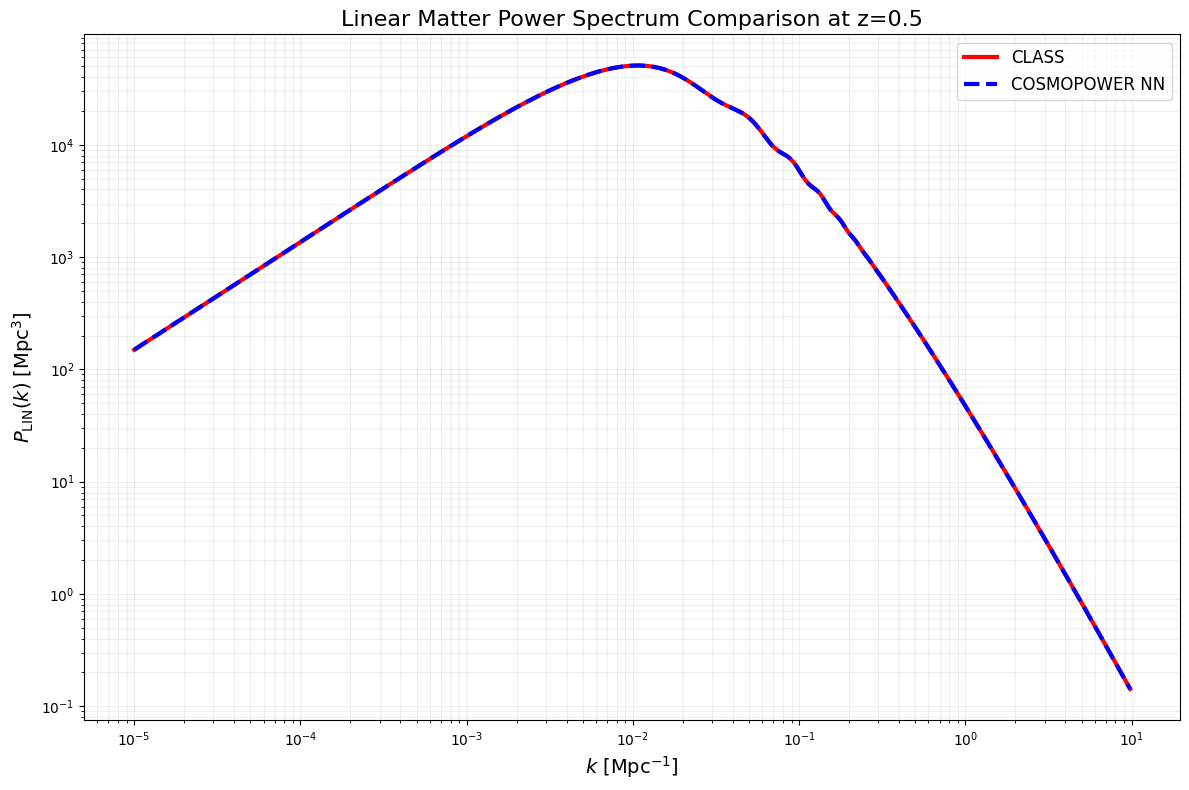

In [ ]:
#Import Required Libraries

import os
import numpy as np
import matplotlib.pyplot as plt
from classy import Class
from scipy.interpolate import interp1d
import cosmopower as cp

# Set up directories and download the pre-trained model
os.makedirs("home", exist_ok=True)
os.makedirs("plots", exist_ok=True)

# Download the pre-trained CosmoPower model
!gdown --id 1h-IxTLoyTE6L3_uE9omjDNC-8X_uVAie -O home/PKLIN_NN.pkl

# Load pre-trained NN model for linear P(k)
cp_nn = cp.cosmopower_NN(restore=True, restore_filename='home/PKLIN_NN')
k_modes = cp_nn.modes

# Cosmological parameters (This dictionary holds standard ΛCDM cosmological parameters at redshift z=0.5)
cosmo_params = {
    'omega_b': 0.0225,
    'omega_cdm': 0.113,
    'h': 0.7,
    'n_s': 0.96,
    'ln10^{10}A_s': 3.07,
    'z': 0.5
}

# Get CosmoPower prediction (Predict P(k) using CosmoPower)

spectrum_cp = cp_nn.ten_to_predictions_np({
    'omega_b': [cosmo_params['omega_b']],
    'omega_cdm': [cosmo_params['omega_cdm']],
    'h': [cosmo_params['h']],
    'n_s': [cosmo_params['n_s']],
    'ln10^{10}A_s': [cosmo_params['ln10^{10}A_s']],
    'z': [cosmo_params['z']]
})[0]

# Get CLASS prediction (Compute CLASS Power Spectrum)
cosmo_class = Class()
params_class = {
    'output': 'mPk',
    'z_max_pk': 5,
    'P_k_max_1/Mpc': 10.,
    'nonlinear_min_k_max': 100.,
    'N_ncdm': 0,
    'omega_b': cosmo_params['omega_b'],
    'omega_cdm': cosmo_params['omega_cdm'],
    'h': cosmo_params['h'],
    'n_s': cosmo_params['n_s'],
    'ln10^{10}A_s': cosmo_params['ln10^{10}A_s'],
}
cosmo_class.set(params_class)
cosmo_class.compute()
spectrum_class = np.array([cosmo_class.pk(ki, cosmo_params['z']) for ki in k_modes])
cosmo_class.struct_cleanup()
cosmo_class.empty()

# Create the comparison plot 
plt.figure(figsize=(12, 8))
plt.loglog(k_modes, spectrum_class, 'red', linewidth=3, label='CLASS')
plt.loglog(k_modes, spectrum_cp, 'blue', linestyle='--', linewidth=3, label='COSMOPOWER NN')

plt.xlabel('$k$ [Mpc$^{-1}$]', fontsize=14)
plt.ylabel('$P_{\mathrm{LIN}}(k)$ [Mpc$^3$]', fontsize=14)
plt.title('Linear Matter Power Spectrum Comparison at z=0.5', fontsize=16)
plt.legend(fontsize=12)
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.tight_layout()

# Save and show the plot
plt.savefig('plots/matter_power_spectrum_class_cosmopower.png', dpi=300, bbox_inches='tight')
plt.show()